# Feature Analysis — Dimensionality &amp; Structure

> **SPI Time Series** · Notebook `02` · Understand what the model sees

This notebook explores the **feature space** that the pipeline builds before
training. It covers all feature categories registered in the config:
**log-based** (control-flow, offers, interactions, waiting states) and
**time-series** (active case counts).

**What you'll find here:**
- Feature extraction via `PipelineBuilder` across different configs
- Dimensionality comparison: one-hot vs. integer-encoded categoricals
- PCA analysis — cumulative explained variance &amp; elbow detection
- Recommended `pca_config.keep_variability` values for each config
- Feature count &amp; type breakdown across enabled feature groups

In [ ]:
from spi_time_series import PipelineBuilder
from pathlib import Path
from spi_time_series.pipeline.pipeline import Pipeline
from spi_time_series.data.schemas import RawData
from spi_time_series.config.schema import RunConfig
from spi_time_series.main import _build_default_feature_extractor

config_log_based = RunConfig.from_yaml(Path("../configs/classification.yaml"))
builder_log_based = PipelineBuilder.from_config(config_log_based)
builder_log_based.with_feature_extractor(
    _build_default_feature_extractor(config_log_based)
)

config_log_based_onehot = RunConfig.from_yaml(
    Path("../configs/classification_onehot.yaml")
)
builder_log_based_onehot = PipelineBuilder.from_config(config_log_based_onehot)
builder_log_based_onehot.with_feature_extractor(
    _build_default_feature_extractor(config_log_based_onehot)
)

config_timeseries = RunConfig.from_yaml(
    Path("../configs/classification_with_active_cases.yaml")
)
builder_timeseries = PipelineBuilder.from_config(config_timeseries)
builder_timeseries.with_feature_extractor(
    _build_default_feature_extractor(config_timeseries)
)


def compute_features(pipeline: Pipeline):
    raw = RawData(event_log=pipeline.dataset.log)
    cleaned = pipeline.preprocessor(raw)
    preprocessed = pipeline.splitter(cleaned)
    features = pipeline.feature_extractor(preprocessed)
    return features

c:\Users\roman\Documents\Uni\Aachen\Semester_3\SoftwarePraktikum\spi-time-series\.venv\Lib\site-packages\pm4py\utils.py:1005: UserWarning: In the current version, the import/export operation uses `r4pm` by default for importing/exporting files faster.
  warnings.warn(


In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt


def pca_analysis(
    X_df,
    y=None,
    n_components=None,
    standardize=True,
):
    """
    Generic PCA analysis for classification or regression targets.

    Parameters
    ----------
    X_df : pd.DataFrame
        Feature dataframe.

    y : pd.Series, np.ndarray or pd.DataFrame
        Optional target.

    n_components : int
        Number of PCs.

    standardize : bool
        Standardize features before PCA.
    """

    X = X_df.select_dtypes(include=np.number)

    if standardize:
        X_scaled = StandardScaler().fit_transform(X)
    else:
        X_scaled = X.values

    pca = PCA(n_components=n_components)
    scores = pca.fit_transform(X_scaled)

    pc_cols = [f"PC{i + 1}" for i in range(scores.shape[1])]
    scores_df = pd.DataFrame(scores, columns=pc_cols, index=X_df.index)

    # ---------------------------------------------------
    # Base PCA plots
    # ---------------------------------------------------

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].bar(
        range(1, len(pca.explained_variance_ratio_) + 1),
        pca.explained_variance_ratio_,
    )
    axes[0].set_title("Explained Variance")

    axes[1].plot(np.cumsum(pca.explained_variance_ratio_), marker="o")
    axes[1].axhline(0.95, color="r", linestyle="--", label="95%")
    axes[1].axhline(0.8, color="r", linestyle="-", label="80%")
    axes[1].set_title("Cumulative Explained Variance")
    axes[1].set_ylim(0, 1.05)

    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------
    # Target-aware plots
    # ---------------------------------------------------

    if y is not None:
        if isinstance(y, pd.DataFrame):
            if y.shape[1] != 1:
                raise ValueError("Only single-target supported.")
            y = y.iloc[:, 0]

        y = pd.Series(y, index=X_df.index)

        is_classification = (
            y.dtype == "object"
            or str(y.dtype) == "category"
            or y.nunique() < 20
        )

        plt.figure(figsize=(7, 6))

        if is_classification:
            for cls in sorted(y.unique()):
                mask = y == cls

                plt.scatter(
                    scores_df.loc[mask, "PC1"],
                    scores_df.loc[mask, "PC2"],
                    alpha=0.7,
                    label=str(cls),
                )

            plt.legend()
            plt.title("PCA Projection by Class")

        else:
            scatter = plt.hexbin(
                scores_df["PC1"], scores_df["PC2"], c=y, cmap="viridis"
            )

            plt.colorbar(scatter, label="Target")
            plt.title("PCA Projection Colored by Target")

        plt.xlabel(f"PC1 ({100 * pca.explained_variance_ratio_[0]:.1f}%)")
        plt.ylabel(f"PC2 ({100 * pca.explained_variance_ratio_[1]:.1f}%)")
        plt.show()

        # ----------------------------------------------
        # Regression-specific diagnostics
        # ----------------------------------------------

        if not is_classification:
            corrs = []

            for col in scores_df.columns:
                corrs.append(scores_df[col].corr(y))

            corrs = pd.Series(corrs, index=scores_df.columns)

            plt.figure(figsize=(8, 4))
            corrs.plot(kind="bar")
            plt.title("Correlation of PCs with Target")
            plt.ylabel("Pearson Correlation")
            plt.show()

    return pca, scores_df

## Classifaction Log Based

Processing cases: 100%|██████████| 623/623 [00:02<00:00, 247.33it/s]


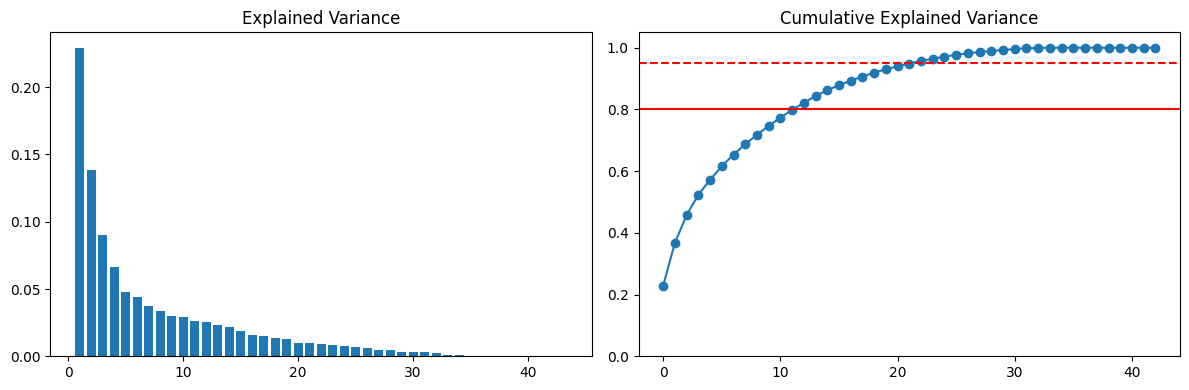

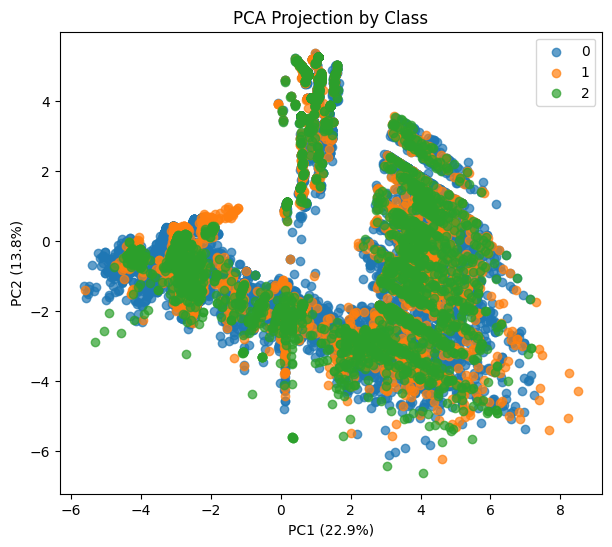

(PCA(),
             PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
 0      1.009814  4.079723 -0.519993  0.557411  0.172520 -0.016692 -1.105151   
 1      0.987150  3.855576 -0.428923  0.467509  0.126683  0.039733 -0.541647   
 2      1.410086  3.868755 -0.517181  0.418970 -0.456678 -0.861136 -0.290274   
 3      4.777911  1.332955  1.389012 -1.298201 -0.195288 -0.576279 -0.930720   
 4      5.198004  0.765685  1.545852 -1.438366 -0.176422 -0.550199 -0.973953   
 ...         ...       ...       ...       ...       ...       ...       ...   
 35912 -4.155884 -0.487284  3.365315  0.505438 -0.939923 -0.876383 -0.742607   
 35913 -4.397069 -0.533078  3.336286 -0.111104  1.384106 -0.446469 -0.843704   
 35914 -3.271358 -0.013515  2.669770 -0.388775  4.986483  1.591535  0.678898   
 35915 -3.314272 -0.093994  2.891532 -0.092180  5.037458  1.616650  0.660196   
 35916 -3.125972 -0.358853  2.808943  0.084722  6.347716  2.389260 -1.118984   
 
             PC8       PC9    

In [3]:
features_set = compute_features(builder_log_based.build())
pca_analysis(features_set.X_train, features_set.y_train)

## Classifaction with Onehot Encoded

In [4]:
features_set = compute_features(builder_log_based_onehot.build())
pca_analysis(features_set.X_train, features_set.y_train)

NameError: name 'builder_log_based_onehot' is not defined

## Classifaction with Timeseries

In [ ]:
features_set = compute_features(builder_timeseries.build())
pca_analysis(features_set.X_train, features_set.y_train)